Loaded cleaned signal (2.0s) and 10 ground-truth click times

Detected 10 clicks

Ground truth: 10 | Detected: 10 | Matched: 10
Precision: 100.0% | Recall: 100.0% | F1: 100.0%

Saved: click_times_detected.npy


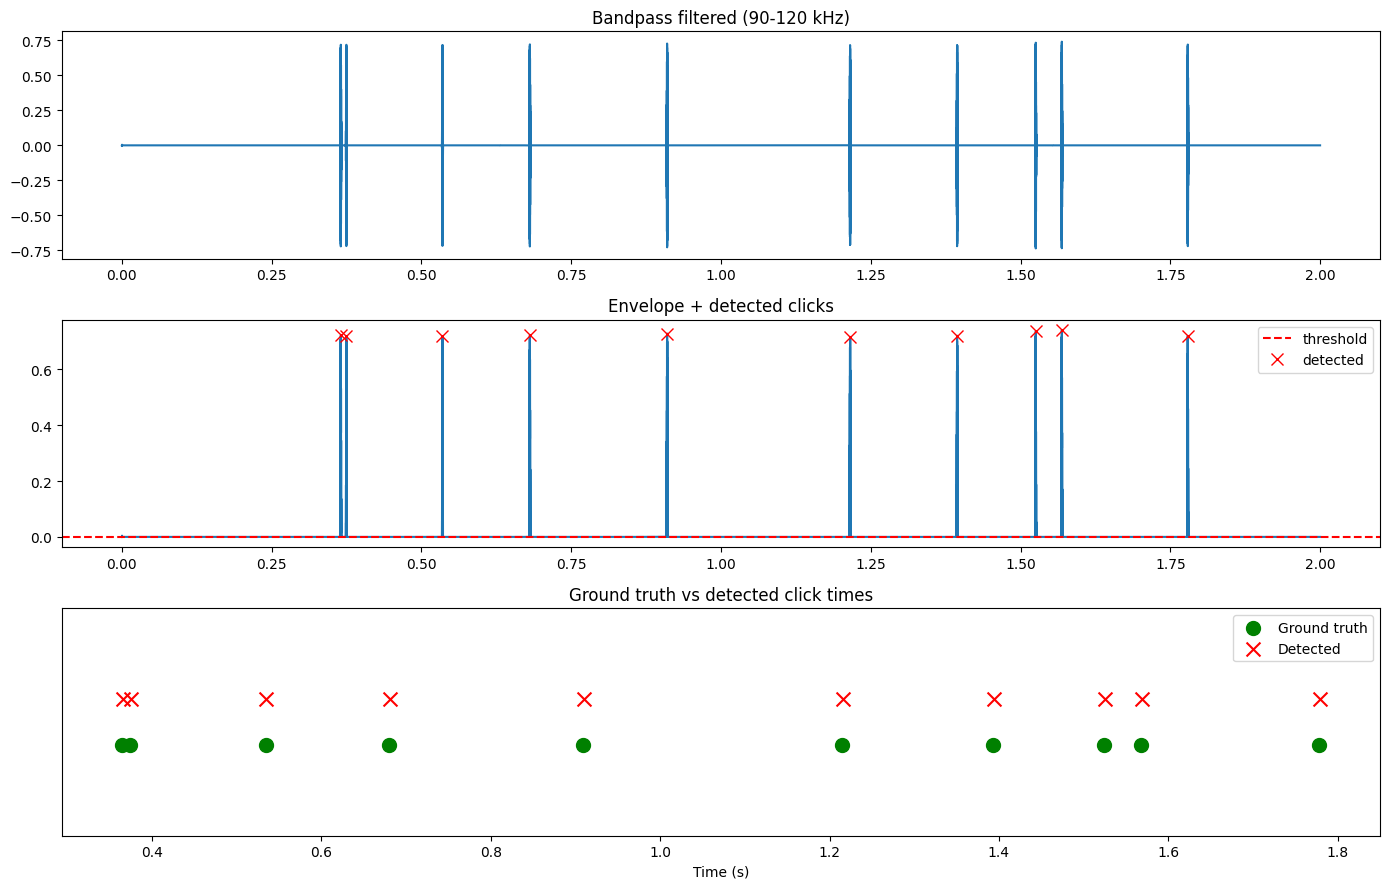

In [2]:
# =============================================================================
# 03_click_detection.ipynb
# Detects clicks from the LMS-cleaned signal and scores against ground truth
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, filtfilt, find_peaks

# --- Load Notebook 2's output + Notebook 1's ground truth ---
fs, cleaned = wavfile.read('cleaned_signal.wav')
cleaned = cleaned.astype(np.float32) / 32767.0
ground_truth = np.load('click_times_ground_truth.npy')
print(f"Loaded cleaned signal ({len(cleaned)/fs:.1f}s) and {len(ground_truth)} ground-truth click times")

def bandpass_filter(sig, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, sig)

def detect_clicks(sig, fs, low=90000, high=120000, threshold_factor=10, min_gap_ms=5, edge_guard_ms=10):
    """
    threshold_factor is relative to the signal's OWN median envelope level,
    not a fixed number -- this makes it adapt to whatever noise floor the
    LMS filter leaves behind, rather than assuming a fixed noise level.

    edge_guard_ms trims detections too close to the start/end of the
    recording, where filtfilt can produce boundary artifacts with no
    real signal behind them.
    """
    filtered = bandpass_filter(sig, low, high, fs)
    envelope = np.abs(filtered)
    threshold = np.median(envelope) * threshold_factor
    min_gap = int(min_gap_ms / 1000 * fs)
    peaks, _ = find_peaks(envelope, height=threshold, distance=min_gap)
    times = peaks / fs

    edge_guard = edge_guard_ms / 1000
    mask = (times > edge_guard) & (times < (len(sig)/fs - edge_guard))
    return times[mask], threshold, envelope, filtered

detected_times, threshold, envelope, filtered = detect_clicks(cleaned, fs)
print(f"\nDetected {len(detected_times)} clicks")

# --- Score against ground truth ---
def score(gt, det, tol_ms=5):
    tol = tol_ms / 1000
    det_list = list(det)
    matches = 0
    for g in gt:
        for d in det_list:
            if abs(d - g) < tol:
                matches += 1
                det_list.remove(d)
                break
    precision = matches / len(det) if len(det) > 0 else 0
    recall = matches / len(gt) if len(gt) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1, matches

precision, recall, f1, matches = score(ground_truth, detected_times)
print(f"\nGround truth: {len(ground_truth)} | Detected: {len(detected_times)} | Matched: {matches}")
print(f"Precision: {precision:.1%} | Recall: {recall:.1%} | F1: {f1:.1%}")

np.save('click_times_detected.npy', np.array(detected_times))
print("\nSaved: click_times_detected.npy")

# --- Plot ---
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
t = np.arange(len(cleaned)) / fs

axes[0].plot(t, filtered)
axes[0].set_title("Bandpass filtered (90-120 kHz)")

axes[1].plot(t, envelope)
axes[1].axhline(threshold, color='r', linestyle='--', label='threshold')
axes[1].plot(detected_times, envelope[(detected_times*fs).astype(int)], 'rx', markersize=8, label='detected')
axes[1].set_title("Envelope + detected clicks")
axes[1].legend()

axes[2].scatter(ground_truth, np.ones_like(ground_truth), color='green', s=100, label='Ground truth', zorder=3)
axes[2].scatter(detected_times, np.ones_like(detected_times)*1.05, color='red', marker='x', s=100, label='Detected', zorder=3)
axes[2].set_ylim(0.9, 1.15); axes[2].set_yticks([])
axes[2].set_xlabel("Time (s)"); axes[2].set_title("Ground truth vs detected click times")
axes[2].legend()

plt.tight_layout()
plt.show()